pag195 - 226

# Probabilities of Default: Continuous-Time Hazard Models

We will start out notebook by loading all datasets that might be useful for us.

In [164]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
import statsmodels.api as sm
from scipy import stats
from scipy.stats import lognorm
from sklearn.metrics import roc_auc_score
from statsmodels.miscmodels.ordinal_model import OrderedModel
from optbinning import OptimalBinning
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
warnings.simplefilter(action='ignore', category=FutureWarning)
from lifelines import KaplanMeierFitter
from lifelines.utils import survival_table_from_events
from lifelines import NelsonAalenFitter
from lifelines.statistics import multivariate_logrank_test
from lifelines import CoxTimeVaryingFitter
from lifelines import CoxPHFitter
from sklearn.preprocessing import StandardScaler
from lifelines import WeibullAFTFitter
from scipy.stats import expon

In [2]:
csvs_path = [rf'datasets/{name}.csv' for name in ['hmeq', 'lgd', 'ratings', 'mortgage']]
hmeq, lgd, ratings, mortgage = list(map(pd.read_csv, csvs_path))

### Introduction

Continuos-time hazar models in a credit risk context describe the survival time of a borrower or loan $T_i (T_i >= 0)$, which is known as time to default, as a random variable in continuous forme. It's generally measured from loan origination.


### Censoring

Censoring is an important characteristic of survival analysis data. It occurs when we have some information about the survival time, but we don't know the exact survival time. There are three types of censoring: right-censoring, left-censoring and interval-censoring.

An observation on an variable T is right-censored if all that you know about T is that is greater than some value. For example, you are tracking how long a laptop battery lasts. After 10 hours, the study ends, but the battery is still working. You know its life is >10 hours, but not exactly how long. The same applies to companies, suppose you are tracking a company up to the age of 50 but you do not know when it will default as you can no longer observe the company, you only know it will be after the age of 50, and so, it's right-censored at age 50.

An observation on a variable T is left-censored if all you know about T is that it is smaller than some value. For example, suppose you are tracking at which age childern learn to ride a bike. A child enters your data at age 5 already knowing how to ride. You know the event happened before age 5 but not the specific date.

An observation on a variable T is interval-censored if all that you know about T is that it is bigger than some value and smaller than some value. In other words, the time of the event is situated in a countinuous internal.

Basically the problem of censoring is that data is missing. In other words, we don't know the precise value of our target variable, which is the timing of the event, but we can specify a lower or upper bound or both. Classical regression approeaches always assume a precise value for the target. hence, new techiques may be used to deal with censored data.


Right-censoring is a significant concern for credit products with limited lifetimes. It occurs when the observation period ends before a default is recorded for several reasons:
* **Loan Maturity:** The bank stops collecting data because the loan term has naturally ended.
* **Early Prepayment:** The borrower pays off the loan early or refinances with a different lender.
* **Binary Outcome:** The observed outcome $\delta_{it}$ is recorded as **1** if a default occurs ($T_i \le t$) and **0** if the data is censored.

The following functions are used to represent the random variable $T$ (time to default):

* **Probability Density Function (PDF):** $f_i(t)$, with the Cumulative Density Function (CDF) defined as $F_i(t) = \int_{-\infty}^{t} f_i(u)du$.
* **Survival Function:** $S_i(t) = 1 - F_i(t)$, representing the probability of no default up to time $t$.
* **Hazard Rate:** $\lambda_i(t)$, the instantaneous rate of default given that the borrower has survived until time $t$:
$$\lambda_i(t) = \lim_{\Delta t \to 0, \Delta t > 0} \frac{1}{\Delta t} P(t \le T_i < t + \Delta t | T_i \ge t) = \frac{f_i(t)}{S_i(t)}$$
* **Cumulative Hazard Rate:** Defined as $\int_{0}^{t} \lambda_i(u)du$, which mathematically equals $-\log S_i(t)$.

There are three primary methods discussed to estimate these functions:
1. **Nonparametric:** Using life tables to observe survival without assuming a specific distribution.
2. **Semiparametric:** Specifically the **Cox Proportional Hazard Model**.
3. **Parametric:** Utilizing **Accelerated Failure Time (AFT)** models.

## Life tables

Life tables models estimate a survival function, which measures the probability of survival based on the consideration of past default times and censoring times. The pd follows as one minus the probability of survival. There are two common-approeaches: Kaplan-Meier analysis and the actuarial method.

### Kaplan-Meier Analysis
The Kaplan-Meier estimator, or product limit estimator, is a nonparametric method used to estimate survival probability $S(t)$.
* **Recursive Formula:** $\hat{S}(t) = \hat{S}(t-1) \times (1 - \frac{d_t}{n_t})$, where $d_t$ is the number of defaults and $n_t$ is the number of individuals at risk at time $t$.
* **At Risk Concept:** "At risk" means the individuals have neither undergone the event (defaulted) nor been censored prior to time $t$.
* **Product Form:** $\hat{S}(t) = \prod_{j:t_j \le t} (1 - \frac{d_j}{n_j})$.

If there is no censoring, then KM estimator for time $t, \hat{S}(t)$ is simply the proportion of observations in the sample with event times greater than $t$.


### Actuarial Method
If there are many unique event times, the **Actuarial Method** (Life Table) is used to group times into intervals.
* **Adjustment for Censoring:** It assumes censoring occurs uniformly across an interval.
* **Adjusted Formula:** $\hat{S}(t) = \prod_{j:t_j \le t} (1 - \frac{d_j}{n_j - c_j/2})$, where $c_j$ represents censored observations in the interval.
* **Effective Sample Size:** The denominator $n_j - c_j/2$ represents the average number of individuals at risk during the interval.

Life tables do not generally condition on observable information (i.e., are nonparametric) and require a cross-sectional form (i.e, one observation per loan). With that in mind, we need to reshape our mortgage data by keeping the last observation and coputing the time in months since the first observation time. Hence, default_time is 0 if an observation is censored and one if a default occurs.

In [3]:
mortgage_ = mortgage.sort_values(['id', 'time'])
mortgage_['time2'] = mortgage_['time'] - mortgage_['first_time'] + 1
mortgage_['is_last_obs'] = mortgage_.groupby('id')['time'].transform('max') == mortgage_['time']
exit_records = mortgage_[(mortgage_['is_last_obs'] == True) | (mortgage_['default_time'] == 1)]
lifetest = exit_records.sort_values(['id', 'time2']).groupby('id').head(1)

In [4]:
idx_ids = lifetest['id'].isin([46,47,56])
lifetest.loc[idx_ids,['id', 'first_time', 'time2','default_time','payoff_time', 'FICO_orig_time', 'LTV_orig_time']]

,id,first_time,time2,default_time,payoff_time,FICO_orig_time,LTV_orig_time
358,46,25,5,1,0,581,80.0
361,47,25,3,0,1,600,80.0
424,56,25,36,0,0,664,52.5


`time2` shows the time to default since the observation period.
- ID 46: `time2` = 5 and `default_time` = 1 - That is, the loan default in the fifith period after first observation
- ID 47: `time2` = 3 and `payoff_time` = 1 - That is, loan has been paid off in the third period after first observation
- ID 56: `time2` = 36 and `default_time` = 0 - That is, the loan is right-censored as we don't know what happened to it after `time` = 36

<Axes: xlabel='timeline'>

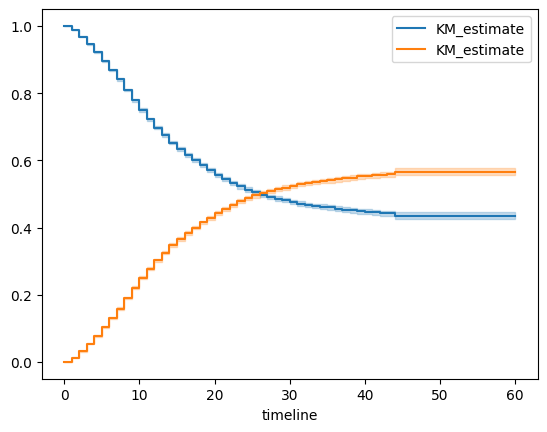

In [5]:
kmf = KaplanMeierFitter()
kmf.fit(durations=lifetest['time2'], event_observed=lifetest['default_time'])
#print(kmf.survival_function_)
kmf.plot_survival_function()
kmf.plot_cumulative_density()

<Axes: >

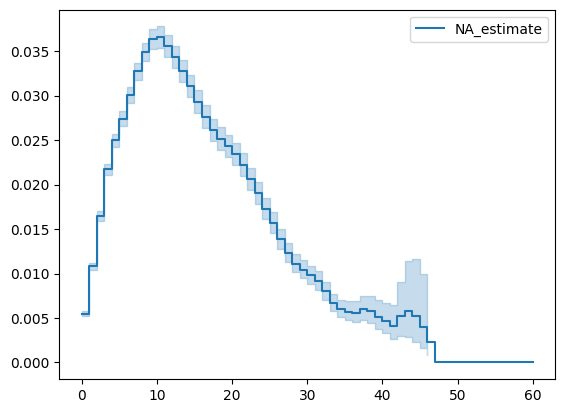

In [6]:
naf = NelsonAalenFitter()
naf.fit(durations=lifetest['time2'], event_observed=lifetest['default_time'])
#naf.plot_cumulative_hazard()
naf.plot_hazard(bandwidth=3)

<Axes: xlabel='timeline'>

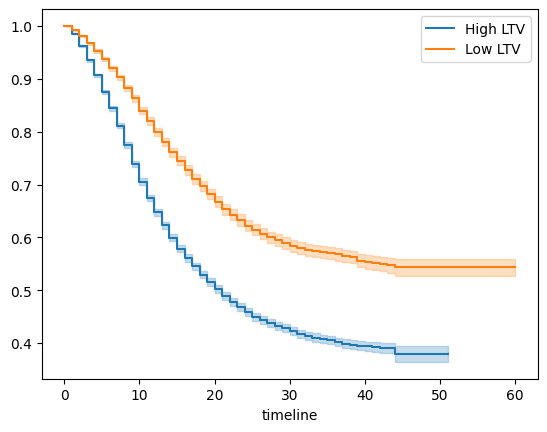

In [7]:
ax = plt.subplot(111)
high_ltv = (lifetest['LTV_orig_time'] >= 80)
kmf.fit(lifetest['time2'][high_ltv], event_observed=lifetest['default_time'][high_ltv], label='High LTV')
kmf.plot_survival_function(ax=ax)
kmf.fit(lifetest['time2'][~high_ltv], event_observed=lifetest['default_time'][~high_ltv], label='Low LTV')
kmf.plot_survival_function(ax=ax)

Here we replicate the Exhibit 7.5 from the book, that shows descriptive statistics for discrete time intervals including the number for failed observations, censored observations and effective sample size (number of observations at the beginning of the time interval less 50 percent of the number of censored observations). We assume that censoring occurs uniformly across the time interval.

- Conditional Probability of Failure: The number of default events divided by the effective sample size for a specific interval.
- Survival Rate: Calculated as 1 minus the current interval's failure probability, multiplied by the previous interval's survival rate.
- Probability Density Function (PDF): The survival rate multiplied by the failure probability, relative to the length of the time interval.
- Hazard Rate: Estimated as the default rate over the midpoint of the survival rate relative to the time interval length.

In [8]:
bins = [0, 10, 20, 30, 40, 50, 200]
labels = ['0-10', '10-20', '20-30', '30-40', '40-50', '50+']
mortgage_plot = lifetest.copy()
mortgage_plot['interval'] = pd.cut(mortgage_plot['time2'], bins=bins, labels=labels, right=False)
table = mortgage_plot.groupby('interval', observed=False).agg(
    no_failed=('default_time', 'sum'),
    no_censored=('default_time', lambda x: (x == 0).sum())
).reset_index()
table['interval'] = table['interval'].astype(str)
total_n = len(lifetest)
table['at_risk'] = total_n - (table['no_failed'] + table['no_censored']).cumsum().shift(1, fill_value=0)
table['E_S_Size'] = table['at_risk'] - (table['no_censored'] / 2)
table['CP_Failure'] = table['no_failed'] / table['E_S_Size']
table['Survival'] = (1 - table['CP_Failure']).cumprod().shift(1, fill_value=1.0)
table['Cumulative_Failure'] = 1 - table['Survival']
eps = 1e-10
variance_term = table['no_failed'] / (table['E_S_Size'] * (table['E_S_Size'] - table['no_failed'] + eps))
sum_var = variance_term.cumsum().shift(1, fill_value=0)
table['SE_Survival'] = table['Survival'] * np.sqrt(sum_var)
table['SE_Cumulative_Failure'] = table['SE_Survival']
h = 10  # Interval width
table['PDF'] = (table['Survival'] * table['CP_Failure']) / h
table['SE_PDF'] = table['PDF'] * np.sqrt(sum_var + ((table['E_S_Size'] - table['no_failed']) / (table['E_S_Size'] * table['no_failed'] + eps)))
q = table['CP_Failure']
table['Hazard'] = (2 * q) / (h * (2 - q + eps))
table['SE_Hazard'] = table['Hazard'] * np.sqrt((1 - (table['Hazard'] * h / 2)**2) / (table['E_S_Size'] * q + eps))
numeric_cols = table.select_dtypes(include=[np.number]).columns
table[numeric_cols] = table[numeric_cols].replace([np.inf, -np.inf], 0).fillna(0)

table

,interval,no_failed,no_censored,at_risk,E_S_Size,CP_Failure,Survival,Cumulative_Failure,SE_Survival,SE_Cumulative_Failure,PDF,SE_PDF,Hazard,SE_Hazard
0,0-10,8243,21300,50000,39350.0,0.209479,1.000000,0.000000,0.000000,0.000000,0.020948,0.000205,0.023399,0.000256
1,10-20,4880,4139,20457,18387.5,0.265398,0.790521,0.209479,0.002051,0.002051,0.020980,0.000263,0.030600,0.000433
2,20-30,1662,2083,11438,10396.5,0.159861,0.580719,0.419281,0.002983,0.002983,0.009283,0.000214,0.017375,0.000425
3,30-40,353,6031,7693,4677.5,0.075468,0.487884,0.512116,0.003261,0.003261,0.003682,0.000190,0.007843,0.000417
4,40-50,16,1286,1309,666.0,0.024024,0.451065,0.548935,0.003556,0.003556,0.001084,0.000268,0.002432,0.000608
5,50+,0,7,7,3.5,0.000000,0.440228,0.559772,0.004382,0.004382,0.000000,0.000000,0.000000,0.000000


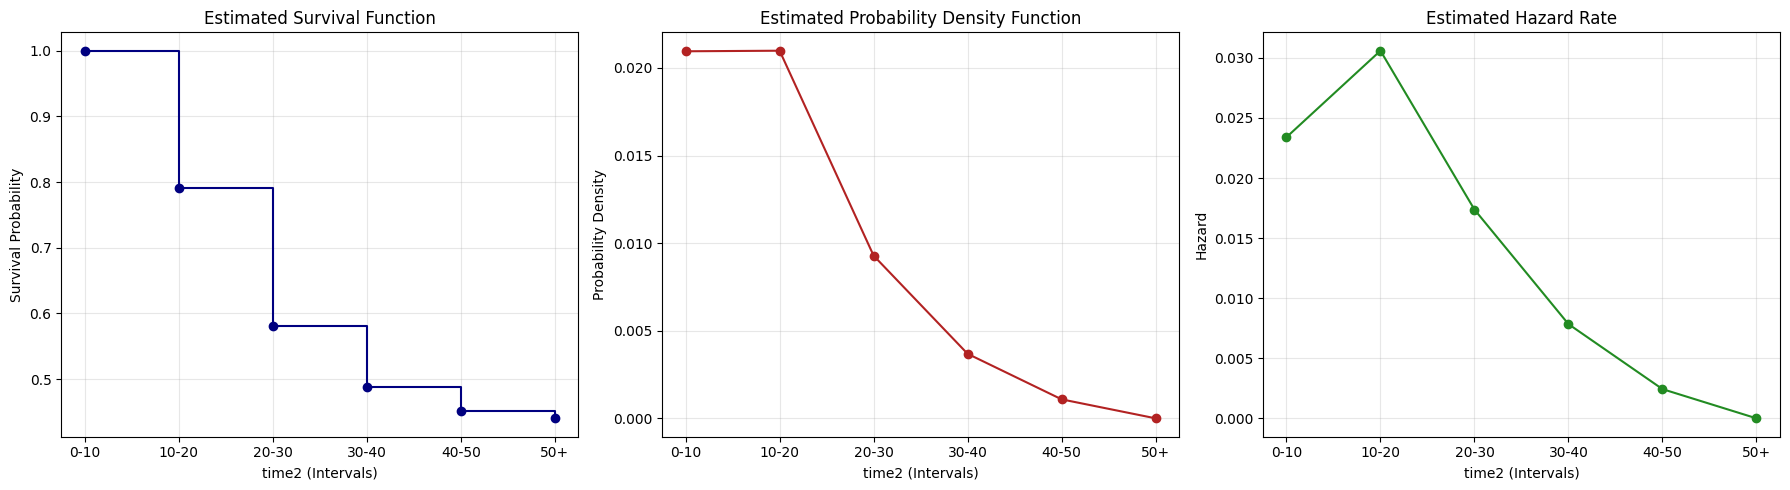

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].step(table['interval'], table['Survival'], where='post', marker='o', color='navy')
axes[0].set_title('Estimated Survival Function')
axes[0].set_ylabel('Survival Probability')
axes[0].set_xlabel('time2 (Intervals)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(table['interval'], table['PDF'], marker='o', linestyle='-', color='firebrick')
axes[1].set_title('Estimated Probability Density Function')
axes[1].set_ylabel('Probability Density')
axes[1].set_xlabel('time2 (Intervals)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(table['interval'], table['Hazard'], marker='o', linestyle='-', color='forestgreen')
axes[2].set_title('Estimated Hazard Rate')
axes[2].set_ylabel('Hazard')
axes[2].set_xlabel('time2 (Intervals)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Life tables are nonparametric and as such do not condition on coltrol information such as borrower, collateral, loan or economic variables. Despite these limitaitons, there is a simple way to inclusde observable information by means of stratification. To demonstrate this points, let's follow the book example and statify the result into five groups of equal size.

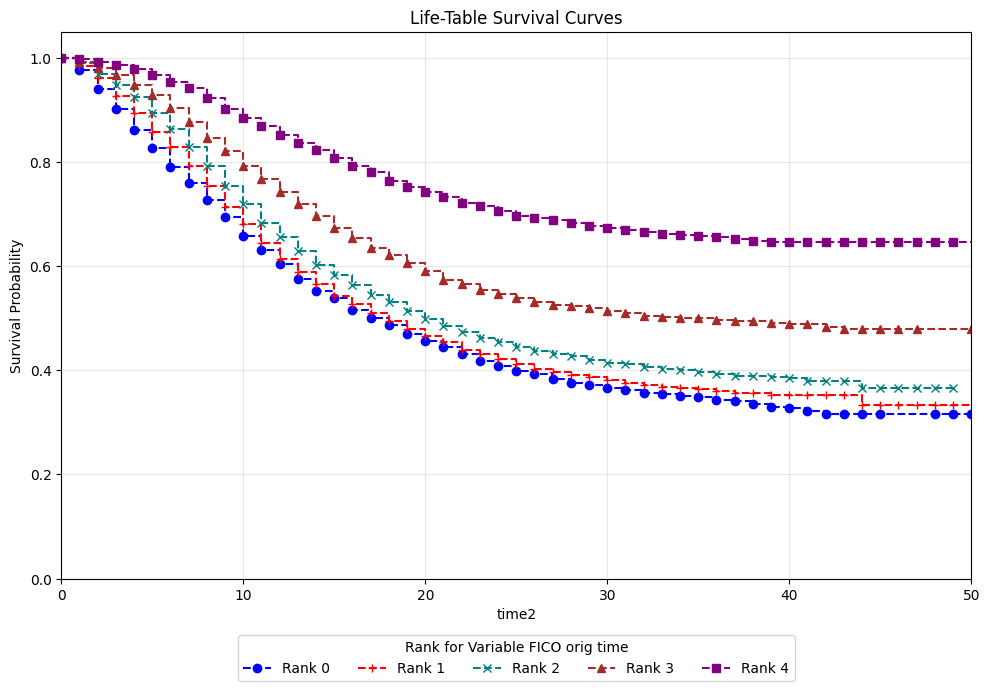

In [10]:
lifetest['FICO_rank'] = pd.qcut(lifetest['FICO_orig_time'], q=5, labels=False)
fig, ax = plt.subplots(figsize=(10, 7))
kmf = KaplanMeierFitter()
styles = [('o', 'blue'), ('+', 'red'), ('x', 'teal'), ('^', 'brown'), ('s', 'purple')]
for rank in range(5):
    subset = lifetest[lifetest['FICO_rank'] == rank]
    kmf.fit(
        durations=subset['time2'], 
        event_observed=subset['default_time'], 
        label=f'Rank {rank}'
    )
    marker, color = styles[rank]
    kmf.plot_survival_function(
        ax=ax, 
        ci_show=False, 
        marker=marker, 
        color=color, 
        linestyle='--'
    )
ax.set_title('Life-Table Survival Curves')
ax.set_xlabel('time2')
ax.set_ylabel('Survival Probability')
ax.set_ylim(0, 1.05)
ax.set_xlim(0, 50)
ax.legend(title='Rank for Variable FICO orig time', loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

It is clear that the FICO score and survival probability are positively correlated. A low FICO score (like rank 0) has a greater default risk, which results in a low survival probability; a high score (like rank 4) has less risk, and a high survival probability.

### Test of Equality over Groups
The Kaplan-Meier estimator does not account for the presence of covariates. It is a very useful tool for exploring and describing your survival data. However, other techniques are needed for building predictive survival analysis. A first extension of Kaplan-Meier analysis is to statistically test the equivalence of survival curves of different samples.

In [11]:
results = []
lr_results = multivariate_logrank_test(lifetest['time2'], lifetest['default_time'], lifetest['FICO_rank'])
results.append({
    'Test': 'Log-Rank',
    'Chi-Square': lr_results.test_statistic,
    'DF': lr_results.degrees_of_freedom,
    'Pr > Chi-Square': lr_results.p_value
})

df_cox = pd.get_dummies(lifetest[['time2', 'default_time', 'FICO_rank']], columns=['FICO_rank'], drop_first=True)
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='time2', event_col='default_time')
lrt = cph.log_likelihood_ratio_test()
results.append({
    'Test': '-2Log(LR)',
    'DF': lrt.degrees_freedom,
    'Pr > Chi-Square': lrt.p_value
})

report = pd.DataFrame(results)
report['Pr > Chi-Square'] = report['Pr > Chi-Square'].apply(lambda x: '<.0001' if x < 0.0001 else f"{x:.4f}")
report

,Test,Chi-Square,DF,Pr > Chi-Square
0,Log-Rank,490.237389,1,<.0001
1,-2Log(LR),NaN,4,<.0001


### Estimation of Default Probabilities

The probability of default between time $t_1$ and $t_2$ ($PD_{t_1,t_2}$) can be calculated as follows:

$$PD_{t_1,t_2} = \frac{S(t_1) - S(t_2)}{S(t_1)}$$

Then, let's do it using our dataset.

In [20]:
life_table = lifetest.groupby('time2')['default_time'].agg(['sum', 'count']).reset_index()
life_table.columns = ['time2', 'n_defaults', 'n_at_risk']
life_table['hazard'] = life_table['n_defaults'] / life_table['n_at_risk']
life_table['survival'] = (1 - life_table['hazard']).cumprod()
t0 = pd.DataFrame({'time2': [0], 'n_defaults': [0], 'n_at_risk': [0], 'hazard': [0], 'survival': [1.0]})
life_table = pd.concat([t0, life_table]).sort_values('time2').reset_index(drop=True)
life_table['lag_survival'] = life_table['survival'].shift(1)
life_table['PD_time'] = (life_table['lag_survival'] - life_table['survival']) / life_table['lag_survival']
life_table.loc[life_table['time2'] == 1, 'PD_time'] = 1 - life_table['survival']
survival2 = life_table.dropna(subset=['PD_time'])[['time2', 'PD_time']]
probabilities = pd.merge(lifetest, survival2, on='time2', how='left')
probabilities['PD_time'] = probabilities['PD_time'].fillna(0)
calibration = probabilities[['default_time', 'PD_time']].mean()
print("Resultados da Calibração (Médias):")
print(calibration)

Resultados da Calibração (Médias):
default_time    0.30308
PD_time         0.30308
dtype: float64


The mean analisys suggests that our calibration is excelent, however, if we plot the data, we can see it's lacking after `time2 >20`, which can be due to the lacking data, volatility of the points or censoring.

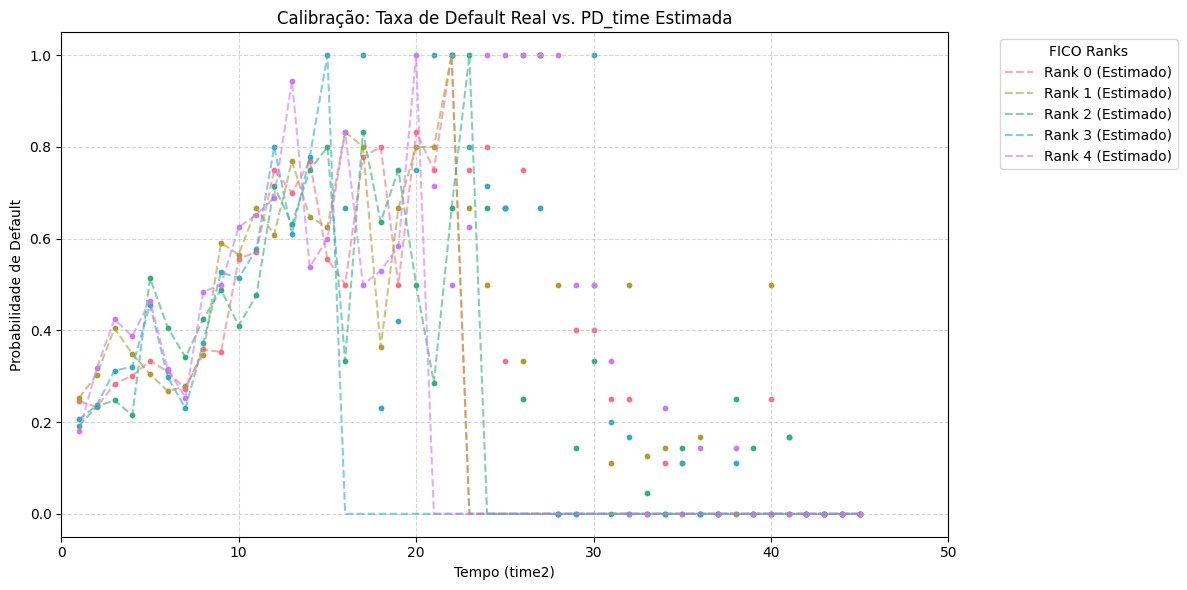

In [30]:
plot_data = probabilities.groupby(['time2', 'FICO_rank'])[['default_time', 'PD_time']].mean().reset_index()
plt.figure(figsize=(12, 6))
colors = sns.color_palette("husl", 5)
for rank in range(5):
    subset = plot_data[plot_data['FICO_rank'] == rank]
    
    plt.plot(subset['time2'], subset['PD_time'], 
             linestyle='--', color=colors[rank], alpha=0.6, 
             label=f'Rank {rank} (Estimado)')
    
    plt.scatter(subset['time2'], subset['default_time'], 
                color=colors[rank], s=10, alpha=1)

plt.title('Calibração: Taxa de Default Real vs. PD_time Estimada')
plt.xlabel('Tempo (time2)')
plt.ylabel('Probabilidade de Default')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='FICO Ranks')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlim(0, 50)
plt.tight_layout()
plt.show()

### Cox Proportional Hazard Models

Cox proportional hazards (CPH) models are regression models that link the survival time under consideration of censoring with predictive covariates. Hence, they are more flexible than the life table approeach and stratification technique in controlling for observable information.

CPH models link the hazard rate with a baseline hazard rate and a transformation of the linear predictor, as follows:

$$\lambda(t|x_i)=\lambda_0(t) \exp(\beta'x_i)$$

where $\lambda_0(t)$ is not specified ($\lambda_0(t) >=0$). CPH models are hence called semiparametric. We restrict the covariates to idiosyncratic information for now.

The survival function of a CPH model is:

$$S(t|\mathbf{x}_i) = \exp \left( -\int_{0}^{t} \lambda(u|\mathbf{x}_i) du \right)$$
$$= \exp \left( -\int_{0}^{t} \lambda_0(u) \exp (\boldsymbol{\beta}' \mathbf{x}_i) du \right)$$
$$= S_0(t)^{\exp (\boldsymbol{\beta}' \mathbf{x}_i)}$$

with

$$S_0(t) = \exp \left( -\int_{0}^{t} \lambda_0(u) du \right)$$

The probability density function of the survival time $T$ is given by:

$$f(t|\mathbf{x}_i) = \lambda(t|\mathbf{x}_i) S(t|\mathbf{x}) = \lambda_0(t) \exp (\boldsymbol{\beta}' \mathbf{x}_i) S_0(t)^{\exp (\boldsymbol{\beta}' \mathbf{x}_i)}$$

If we now introduce an indicator variable for borrower $i, \delta_i$, whereby $\delta_i = 0$ if censoring occurs and $\delta_i = 1$ if default occurs, then the likelihood for all observations becomes:

$$L(\lambda_0(t), \boldsymbol{\beta}, \mathbf{x}_i) = \prod_{i=1}^{N} f_i(t_i)^{\delta_i} S_i(t_i)^{1-\delta_i}$$
$$= \prod_{i=1}^{N} [\lambda_0(t_i) \exp (\boldsymbol{\beta}' \mathbf{x}_i)]^{\delta_i} \exp \left[ -\int_{0}^{t_i} \lambda_0(u) \exp (\boldsymbol{\beta}' \mathbf{x}_i) du \right]$$

#### Partial Likelihood

Let's now discuss how the $\beta$ parameters of a proporcional hazards regression model can be estimated using the idea of partial likelihood. Suppose we have *I* individuals with *i* ranging from one to *I*. Each individual has three characteristics: $x_i$, is the vector of covariates, $t_i$, is the time of the event of censoring, and $\delta_i$ is one if the iondividual is uncensored and zero if the individual is censored. We start by ranking all events of the noncensored subjects ($t_1$ up to $t_T$). Given the fact that one subject has event time $t_i$, the probability that this subject has inputs $x_j$ is then given by:

$$\frac{\lambda(t_i|\mathbf{x}_i)\Delta t}{\sum_{l \in R(t_i)} h(t_i, \mathbf{x}_l)\Delta t}$$

where $R(t_i)$ represents the subjects that are at risk at time $t_i$. Since the baseline hazard $\lambda_0(t_i)$ occurs in both the numerator and the denominator, it will cancel out. Hence, this gives us the folowwing expression:

$$\frac{\exp (\boldsymbol{\beta}'\mathbf{x}_i)}{\sum_{l \in R(t_i)} \exp (\boldsymbol{\beta}'\mathbf{x}_l)}$$

which is independent of the baseline hazard. The partial likelihood function then becomes:

$$\prod_{j=1}^{I} \frac{\exp (\boldsymbol{\beta}'\mathbf{x}_i)}{\sum_{l \in R(t_i)} \exp (\boldsymbol{\beta}'\mathbf{x}_l)}$$

More than how to derivate the functions, the book gives some tips, like:

- $\beta$ can be optmized using Newton-Raphson and can be estimated without having to specify the baseline hazard $\theta_0(t)$.
- Its assumed that individual $j$ with covariates $x_j$ has event time $t_j$

I will avoid trying to resume all of those as this notebook is already big as it is, let's try the equivalent python implementation.

In [45]:
cols = ['time2', 'default_time', 'FICO_orig_time', 'LTV_orig_time']
df_cph = lifetest[cols]
cph = CoxPHFitter()
cph.fit(df_cph, duration_col='time2', event_col='default_time')
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 50000 total observations, 34846 right-censored observations>
             duration col = 'time2'
                event col = 'default_time'
      baseline estimation = breslow
   number of observations = 50000
number of events observed = 15154
   partial log-likelihood = -150534.32
         time fit was run = 2026-03-01 11:49:18 UTC

---
                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                       
FICO_orig_time -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
LTV_orig_time   0.02      1.02      0.00            0.01            0.02                1.01                1.02

                cmp to      z      p  -log2(p)
covariate                                     
FICO_orig_time    0.00 -39.64 <0.005       inf
LTV_orig_time     0.00  19.38 <0.005    275.57
---
Concordance = 0.63
Partial AIC = 301072.64
log-likelihood ratio test = 2164.11 on 2 df
-log2(p) of ll-ratio test = inf

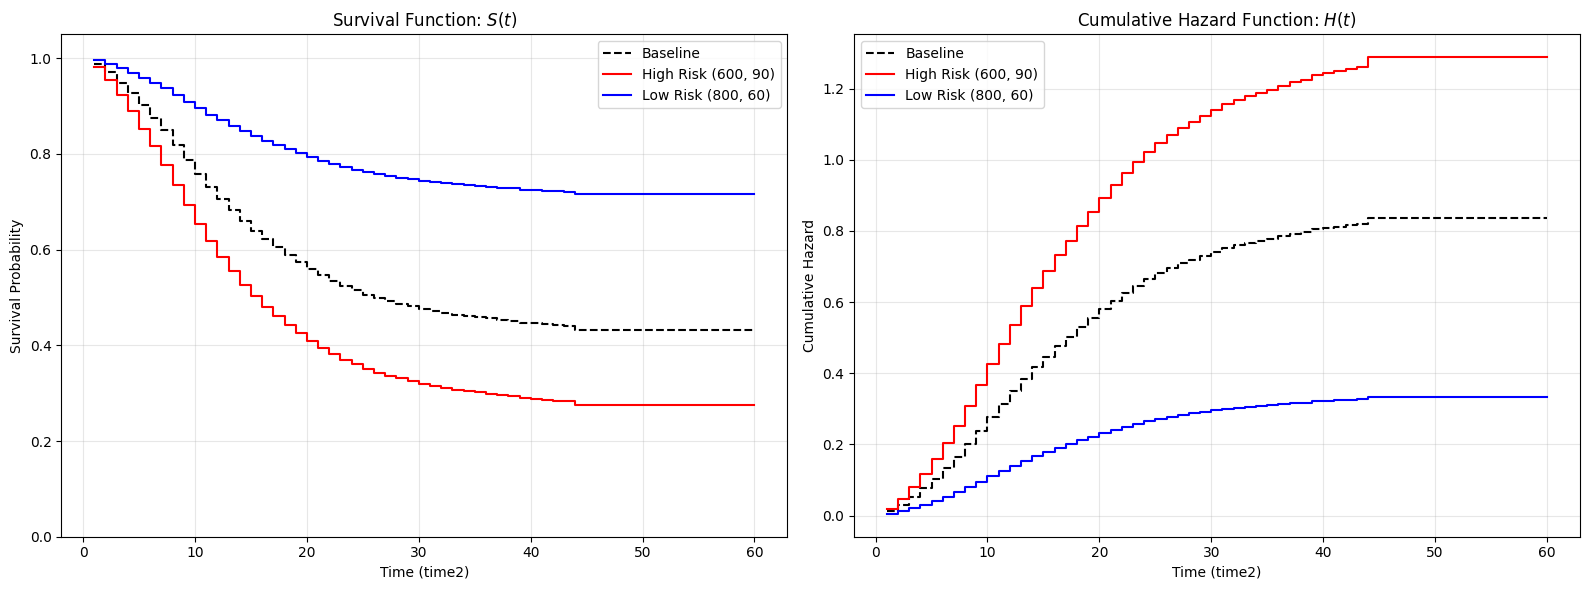

In [55]:
scenarios = pd.DataFrame({
    'FICO_orig_time': [600, 800],
    'LTV_orig_time': [90, 60]
}, index=['High Risk (600, 90)', 'Low Risk (800, 60)'])
survival_scenarios = cph.predict_survival_function(scenarios)
cum_hazard_scenarios = cph.predict_cumulative_hazard(scenarios)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.step(cph.baseline_survival_.index, cph.baseline_survival_.values, 
         label='Baseline', color='black', linestyle='--', where='post')

ax1.step(survival_scenarios.index, survival_scenarios['High Risk (600, 90)'], 
         label='High Risk (600, 90)', color='red', where='post')
ax1.step(survival_scenarios.index, survival_scenarios['Low Risk (800, 60)'], 
         label='Low Risk (800, 60)', color='blue', where='post')

ax1.set_title('Survival Function: $S(t)$')
ax1.set_xlabel('Time (time2)')
ax1.set_ylabel('Survival Probability')
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.step(cph.baseline_cumulative_hazard_.index, cph.baseline_cumulative_hazard_.values, 
         label='Baseline', color='black', linestyle='--', where='post')
ax2.step(cum_hazard_scenarios.index, cum_hazard_scenarios['High Risk (600, 90)'], 
         label='High Risk (600, 90)', color='red', where='post')
ax2.step(cum_hazard_scenarios.index, cum_hazard_scenarios['Low Risk (800, 60)'], 
         label='Low Risk (800, 60)', color='blue', where='post')

ax2.set_title('Cumulative Hazard Function: $H(t)$')
ax2.set_xlabel('Time (time2)')
ax2.set_ylabel('Cumulative Hazard')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
lifetest_with_dummies = pd.get_dummies(lifetest, columns=['FICO_rank'], drop_first=True)
cph_rank = CoxPHFitter()
cph_rank.fit(
    lifetest_with_dummies[['time2', 'default_time', 'LTV_orig_time'] + 
                          [c for c in lifetest_with_dummies.columns if 'FICO_rank_' in c]],
    duration_col='time2', 
    event_col='default_time'
)
avg_ltv = df_cph['LTV_orig_time'].mean()
cph_rank.print_summary()

<lifelines.CoxPHFitter: fitted with 50000 total observations, 34846 right-censored observations>
             duration col = 'time2'
                event col = 'default_time'
      baseline estimation = breslow
   number of observations = 50000
number of events observed = 15154
   partial log-likelihood = -151193.82
         time fit was run = 2026-03-01 11:49:27 UTC

---
               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                      
LTV_orig_time  0.02      1.02      0.00            0.02            0.02                1.02                1.02
FICO_rank_1.0  0.43      1.54      0.05            0.33            0.53                1.39                1.70
FICO_rank_2.0  0.42      1.53      0.05            0.32            0.53                1.38                1.70
FICO_rank_3.0  0.36      1.44      0.06            0.25            0.47                1.29                1.60
FICO_rank_4.0  0.49      1.63      0.05            0.39            0.59                1.47                1.80

               cmp to     z      p  -log2(p)
covariate                                   
LTV_orig_time    0.00 24.55 <0.005    439.62
FICO_rank_1.0    0.00  8.39 <0.005     54.19
FICO_rank_2.0    0.00  7.98 <0.005     49.23
FICO_rank_3.0    0.00  6.53 <0.005     33.85
FICO_rank_4.0    0.00  9.50 <0.005     68.71
---
Concordance = 0.58
Partial AIC = 302397.63
log-likelihood ratio test = 845.11 on 5 df
-log2(p) of ll-ratio test = 596.94

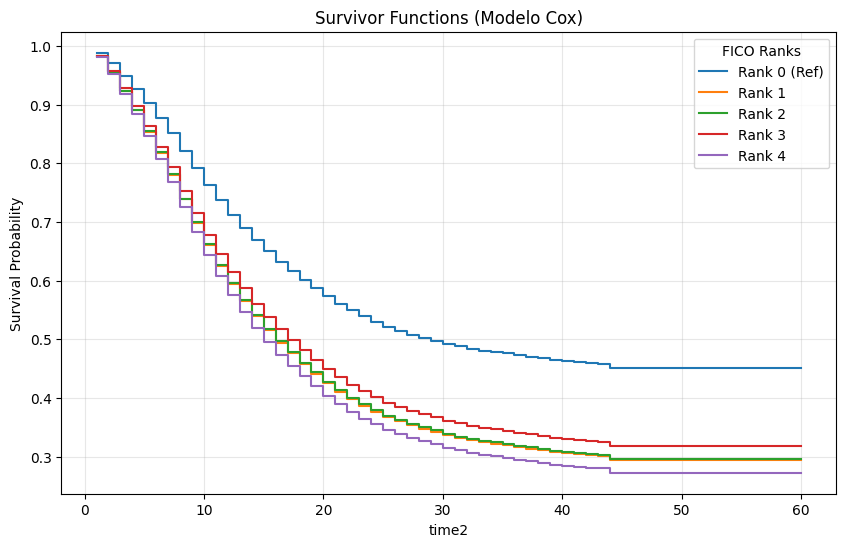

In [50]:
# Criamos uma linha para cada Rank (0 a 4)
cenarios = pd.DataFrame({
    'LTV_orig_time': [avg_ltv] * 5,
    'FICO_rank_1.0': [0, 1, 0, 0, 0],
    'FICO_rank_2.0': [0, 0, 1, 0, 0],
    'FICO_rank_3.0': [0, 0, 0, 1, 0],
    'FICO_rank_4.0': [0, 0, 0, 0, 1]
}, index=['Rank 0 (Ref)', 'Rank 1', 'Rank 2', 'Rank 3', 'Rank 4'])

# 4. Gerar e Plotar as Curvas de Sobrevivência (Equivalente ao Exhibit 7.14)
plt.figure(figsize=(10, 6))
cph_rank.predict_survival_function(cenarios).plot(ax=plt.gca(), drawstyle="steps-post")

plt.title('Survivor Functions (Modelo Cox)')
plt.ylabel('Survival Probability')
plt.xlabel('time2')
plt.grid(True, alpha=0.3)
plt.legend(title='FICO Ranks')
plt.show()

### Time-Varying Information

Time-varying information is a key concern in credit risk modeling. CPH models are able to accomodate time-vayring explanatory variables as discrete-time hazard models.

$$\lambda(t|x_{it-1})=\lambda_0(t)\exp(\beta'x_{it-1})$$

There are two main ways to include time-varying covariates: first, the aggregation of time-varying information and second, counting process data.

#### Time-Varying Covariates: Aggregation of Time-Varying Information

In [64]:
from lifelines import CoxPHFitter
cph = CoxPHFitter()
cph.fit(
    lifetest.dropna(), 
    duration_col='time2', 
    event_col='default_time', 
    formula="FICO_orig_time + LTV_time + gdp_time"
)
print(cph.summary[['coef', 'se(coef)', 'p', 'exp(coef)']])

                    coef  se(coef)             p  exp(coef)
covariate                                                  
FICO_orig_time -0.002434  0.000413  3.706175e-09   0.997569
LTV_time        0.011967  0.000962  1.583544e-35   1.012039
gdp_time       -0.130879  0.011350  9.192962e-31   0.877324


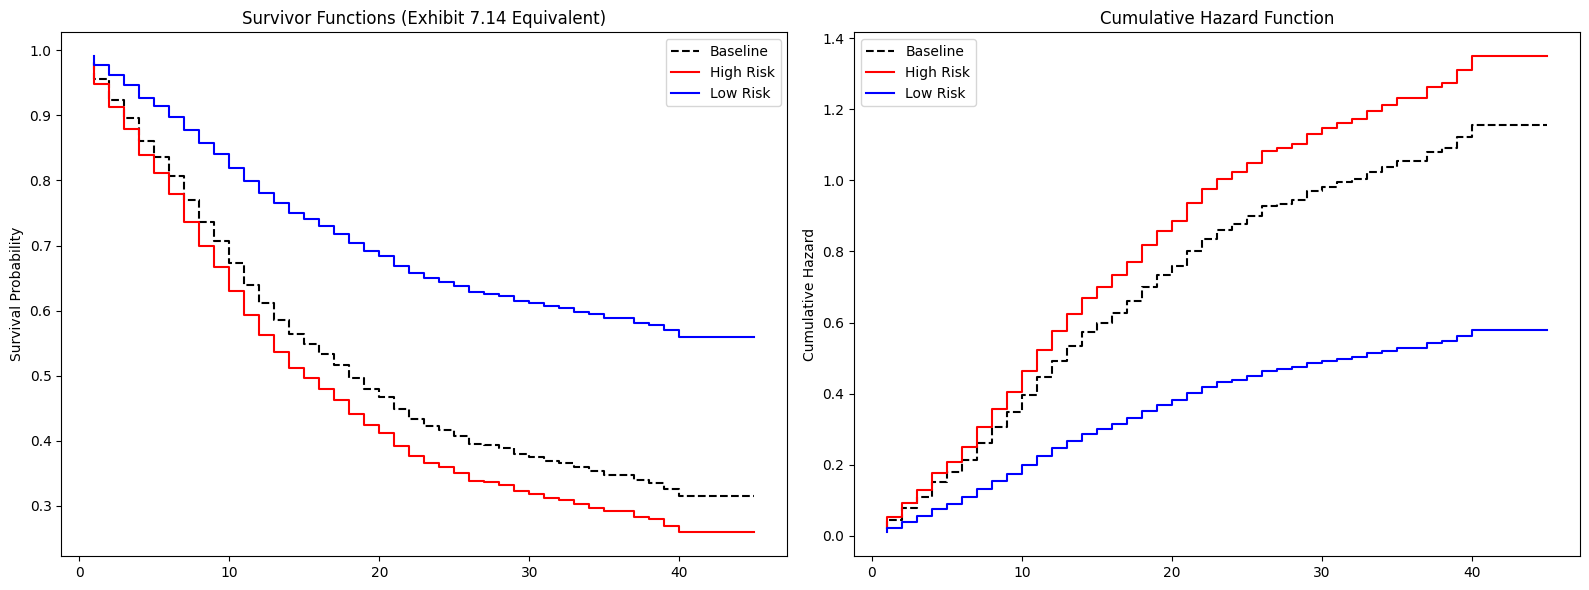

In [ ]:
scenarios = pd.DataFrame({
    'FICO_orig_time': [600, 800],
    'LTV_time': [90, 60],
    'gdp_time': [lifetest['gdp_time'].mean(), lifetest['gdp_time'].mean()] # Assuming mean GDP for baseline
}, index=['High Risk (FICO 600, LTV 90)', 'Low Risk (FICO 800, LTV 60)'])

survival_scen = cph.predict_survival_function(scenarios)
hazard_scen = cph.predict_cumulative_hazard(scenarios)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.step(cph.baseline_survival_.index, cph.baseline_survival_.values, label='Baseline', color='black', linestyle='--')
ax1.step(survival_scen.index, survival_scen.iloc[:, 0], label='High Risk', color='red')
ax1.step(survival_scen.index, survival_scen.iloc[:, 1], label='Low Risk', color='blue')
ax1.set_title('Survivor Functions (Exhibit 7.14 Equivalent)')
ax1.set_ylabel('Survival Probability')
ax1.legend()

ax2.step(cph.baseline_cumulative_hazard_.index, cph.baseline_cumulative_hazard_.values, label='Baseline', color='black', linestyle='--')
ax2.step(hazard_scen.index, hazard_scen.iloc[:, 0], label='High Risk', color='red')
ax2.step(hazard_scen.index, hazard_scen.iloc[:, 1], label='Low Risk', color='blue')
ax2.set_title('Cumulative Hazard Function')
ax2.set_ylabel('Cumulative Hazard')
ax2.legend()

plt.tight_layout()
plt.show()

#### Time-Varying Covariates: Counting Process Data

The counting process data style of input requires the data to be in panel form and two additional time stamps relative to the first observation time:
- The time from first loan observation to the beginning of an observation period
- The time from the first loan observation to the end of an observation period.

In [70]:
mortgage_['time1'] = mortgage_['time'] - mortgage_['first_time']
mortgage_['time2'] = mortgage_['time1'] + 1

# Reordering columns to match Exhibit 7.16 exactly
cols = ['id', 'first_time', 'time', 'time1', 'time2', 'default_time', 'payoff_time', 'FICO_orig_time', 'gdp_time']
idx = mortgage_['id'].isin([46,47])
phreg = mortgage_.copy()
phreg.loc[idx,cols]

,id,first_time,time,time1,time2,default_time,payoff_time,FICO_orig_time,gdp_time
354,46,25,25,0,1,0,0,581,2.899137
355,46,25,26,1,2,0,0,581,2.151365
356,46,25,27,2,3,0,0,581,2.361722
357,46,25,28,3,4,0,0,581,1.229172
358,46,25,29,4,5,1,0,581,1.692969
359,47,25,25,0,1,0,0,600,2.899137
360,47,25,26,1,2,0,0,600,2.151365
361,47,25,27,2,3,0,1,600,2.361722


In [96]:
cols_to_scale = ['FICO_orig_time', 'LTV_time', 'gdp_time']
scaler = StandardScaler()
#phreg_scaled = phreg.dropna()
#phreg_scaled[cols_to_scale] = scaler.fit_transform(phreg_scaled[cols_to_scale])
model_cols = [
    'id', 'time1', 'time2', 'default_time',  # Structural columns
    'FICO_orig_time', 'LTV_time', 'gdp_time' # Specific Covariates
]
ctv = CoxTimeVaryingFitter(penalizer=0) 
ctv.fit(
    phreg[model_cols].dropna(), 
    id_col="id", 
    event_col="default_time", 
    start_col="time1", 
    stop_col="time2",
    show_progress=False
)

ctv.summary

,coef,exp(coef),se(coef),coef lower 95%,coef upper 95%,exp(coef) lower 95%,exp(coef) upper 95%,cmp to,z,p,-log2(p)
covariate,,,,,,,,,,,
FICO_orig_time,-0.005197,0.994817,0.000113,-0.005417,-0.004976,0.994597,0.995036,0.0,-46.143227,0.000000e+00,inf
LTV_time,0.008737,1.008775,0.000126,0.008490,0.008984,1.008527,1.009024,0.0,69.412066,0.000000e+00,inf
gdp_time,-0.102856,0.902257,0.003950,-0.110598,-0.095115,0.895299,0.909269,0.0,-26.040128,1.740468e-149,494.167811


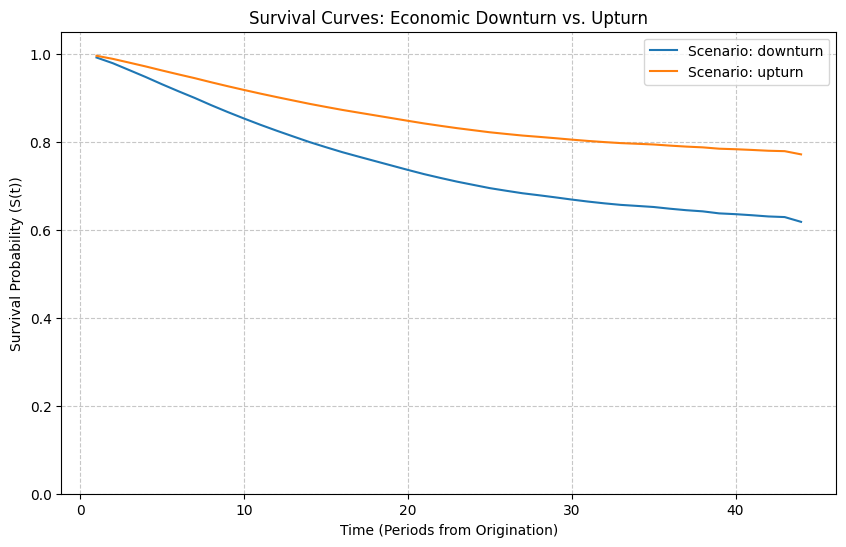

In [98]:
covariates_time = pd.DataFrame([
    ['downturn', 800, 60, -3],
    ['upturn', 800, 60, 3]
], columns=['set', 'FICO_orig_time', 'LTV_time', 'gdp_time']).set_index('set')

#covariates_time_scaled = pd.DataFrame(
#    scaler.transform(covariates_time),
#    columns=covariates_time.columns,
#    index=covariates_time.index
#)
partial_hazards = ctv.predict_partial_hazard(covariates_time)
partial_hazards.index = covariates_time.index
b_hazard = ctv.baseline_cumulative_hazard_.iloc[:, 0]
plt.figure(figsize=(10, 6))

for scenario in covariates_time.index:
    phi = partial_hazards.loc[scenario]
    s_t = np.exp(-b_hazard * phi)
    plt.plot(s_t.index, s_t.values, label=f"Scenario: {scenario}")

plt.title("Survival Curves: Economic Downturn vs. Upturn")
plt.xlabel("Time (Periods from Origination)")
plt.ylabel("Survival Probability (S(t))")
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

So, this part of the book I wrote and rewrote until I got mostly close to the books results. The reason for it? Samplying, it should be quite obvious, but when doing studies like these where I will be comparing to mean it's better to ensure that the proportion of defaults in the sample matches the proportion of the population.

                    coef  exp(coef)  se(coef)         z             p
covariate                                                            
FICO_orig_time -0.000987   0.999014  0.000294 -3.359605  7.805412e-04
LTV_time        0.005461   1.005476  0.001030  5.302687  1.141107e-07
gdp_time       -0.039723   0.961056  0.011545 -3.440813  5.799688e-04


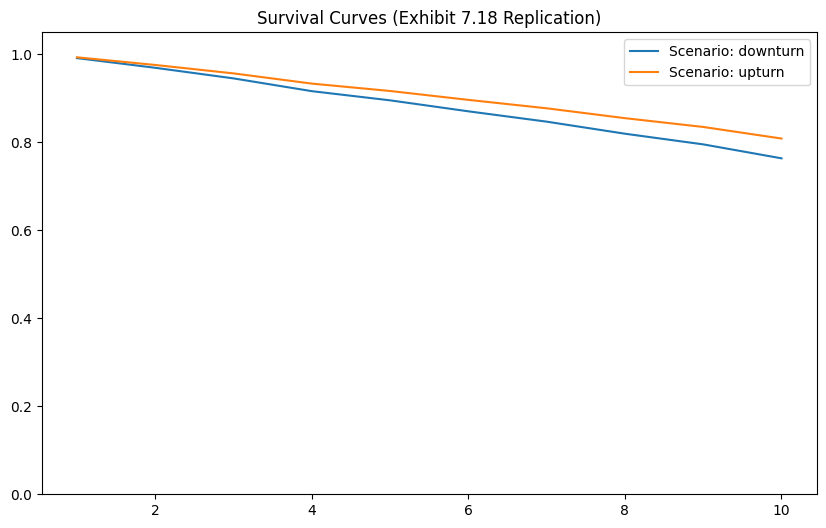

In [122]:
phreg2 = phreg[phreg['time2'] <= 10][model_cols].dropna()
#unique_ids = phreg2['id'].unique()
#sampled_ids = pd.Series(unique_ids).sample(frac=0.05, random_state=12345)
#phreg3 = phreg2[phreg2['id'].isin(sampled_ids)].copy()
id_defaults = phreg2.groupby('id')['default_time'].max()
gss = GroupShuffleSplit(n_splits=1, train_size=0.05, random_state=12345)
train_idx, _ = next(gss.split(phreg2, groups=phreg2['id'], y=phreg2['id'].map(id_defaults)))
phreg3 = phreg2.iloc[train_idx].copy()

#phreg3 = phreg2.sample(frac=0.05, random_state=12345)
ctv = CoxTimeVaryingFitter(penalizer=0.1)
ctv.fit(
    phreg3,
    id_col="id",
    event_col="default_time",
    start_col="time1",
    stop_col="time2",
    show_progress=False
)

print(ctv.summary[['coef', 'exp(coef)', 'se(coef)', 'z', 'p']])

phreg3['partial_hazard'] = ctv.predict_partial_hazard(phreg3)
b_hazard_df = ctv.baseline_cumulative_hazard_
b_hazard_df.iloc[:, 0].reindex(phreg3['time2'], method='ffill')
phreg3['baseline_H0'] = phreg3['time2'].map(b_hazard_df.iloc[:, 0])
phreg3['survival'] = np.exp(-phreg3['baseline_H0'] * phreg3['partial_hazard'])

partial_hazards = ctv.predict_partial_hazard(covariates_time)
partial_hazards.index = covariates_time.index
b_hazard = ctv.baseline_cumulative_hazard_.iloc[:, 0]
plt.figure(figsize=(10, 6))
for scenario in covariates_time.index:
    phi = partial_hazards.loc[scenario]
    s_t = np.exp(-b_hazard * phi)
    plt.plot(s_t.index, s_t.values, label=f"Scenario: {scenario}")
plt.title("Survival Curves (Exhibit 7.18 Replication)")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

### Estimation of Default Probabilities

We now compute the PD as the first-order difference of the cumulative hazard rate of the current observation and the observation in the previous period $\frac{S(t_1)-(S(t_2))}{S(t_1)}$

In [124]:
phreg3 = phreg3.sort_values(by=['id', 'time2'])
phreg3['lag_survival'] = phreg3.groupby('id')['survival'].shift(1)
phreg3['PD_time'] = np.where(
    phreg3['time2'] == 1,
    1 - phreg3['survival'],
    (phreg3['lag_survival'] - phreg3['survival']) / phreg3['lag_survival']
)
probabilities = phreg3[['id', 'time2', 'FICO_orig_time', 'LTV_time', 'gdp_time', 'survival', 'lag_survival', 'PD_time', 'default_time']]

probabilities[['PD_time', 'default_time']].mean()

PD_time         0.026917
default_time    0.027264
dtype: float64

### Accelerated Failure Time Models

Accelerated failure time (AFT) models are parametric survival models that link the (log) transformed survival time to a linear predictor of the sum of parameter-weighted covariates:
$$log(T_i)= \beta'x_i+\sigma\epsilon$$

where $T_i$ is the time to failure. The parameter $\beta_i$ indicates how strongly the survival time accelerates or decelerates when a coviariate changes by one unit.

The hazard function $\lambda(t)$ is defined as the negative derivative of $\log S(t)$ with respect to $t$. Consequently, $-\log S(t)$ represents the cumulative hazard function, interpreted as the sum of risks faced from time $0$ to time $t$.

#### Diagnostic Plotting for Distributions:
* **Exponential**: Plotting $-\log(S(t))$ against $t$ yields a straight line through the origin.
* **Weibull**: Plotting $\log(-\log(S(t)))$ against $\log(t)$ yields a straight line.
* **Lognormal**: Plotting $N^{-1}(1 - S(t))$ against $\log(t)$ yields a straight line.
* **Log-logistic**: Plotting $\log((1 - S(t))/S(t))$ against $\log(t)$ yields a straight line.


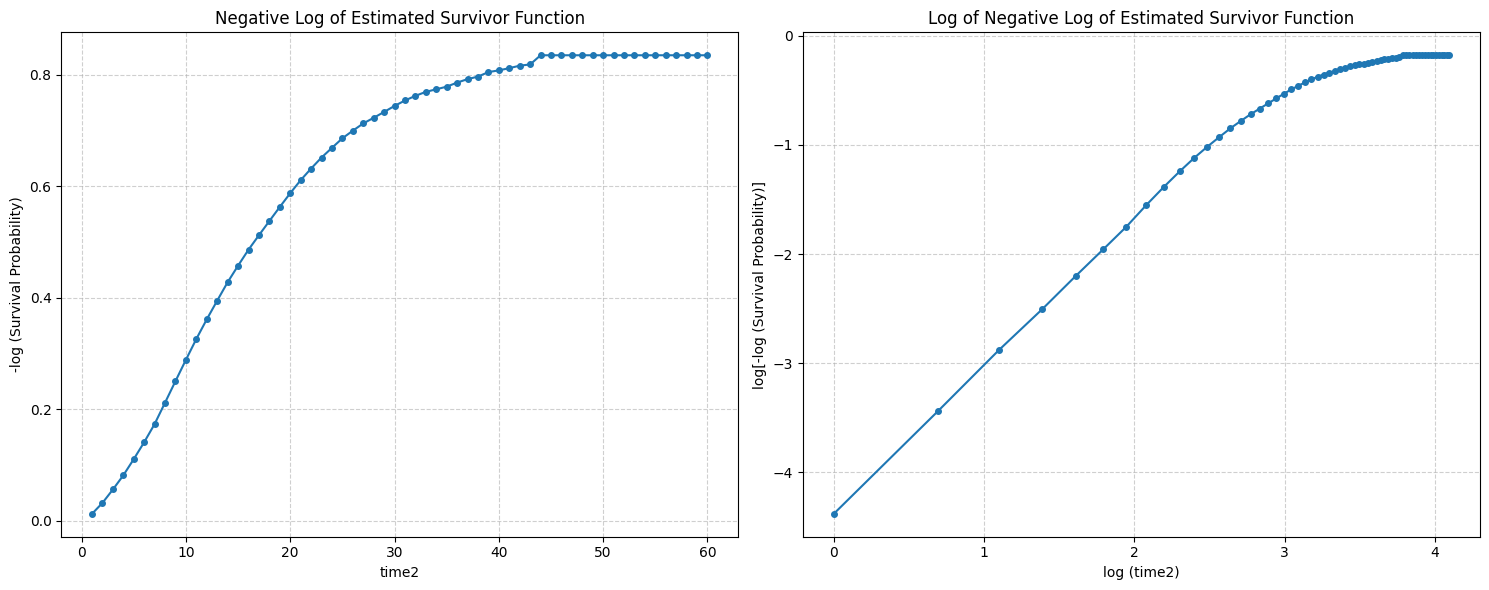

In [ ]:
lifetable = phreg.groupby('time2').agg(
    total=('default_time', 'count'),
    defaults=('default_time', 'sum')
)
lifetable['cond_survival'] = 1 - (lifetable['defaults'] / lifetable['total'])
lifetable['survival'] = lifetable['cond_survival'].cumprod()
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].plot(lifetable.index, -np.log(lifetable['survival']), 'o-', markersize=4)
axes[0].set_title("Negative Log of Estimated Survivor Function")
axes[0].set_xlabel("time2")
axes[0].set_ylabel("-log (Survival Probability)")
axes[0].grid(True, linestyle='--', alpha=0.6)

valid = lifetable[lifetable.index > 0].copy()
axes[1].plot(np.log(valid.index), np.log(-np.log(valid['survival'])), 'o-', markersize=4)
axes[1].set_title("Log of Negative Log of Estimated Survivor Function")
axes[1].set_xlabel("log (time2)")
axes[1].set_ylabel("log[-log (Survival Probability)]")
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### Likelihood Procedure

A more formal approeach to evaluate model fit is based on a likelihood procedure. More specifically, the likelihood ratio test statistic can be used to compare models and test if one model is a special case of another. Let's start from the generalized gamma distribution:

$$f(t) = \frac{\beta}{\Gamma(\kappa)\theta} \left( \frac{t}{\theta} \right)^{\kappa\beta - 1} \exp \left( -\left( \frac{t}{\theta} \right)^\beta \right)$$

By defining $\sigma = 1/(\beta\sqrt{\kappa})$ and $\delta = 1/\sqrt{\kappa}$, we can identify the following special versions:

| Distribution | Parameter Condition |
| :--- | :--- |
| **Standard Gamma** | $\sigma = \delta$ |
| **Weibull** | $\delta = 1$ |
| **Exponential** | $\sigma = 1$ and $\delta = 1$ |
| **Lognormal** | $\delta = 0$ |

We can now use this to perform a likelihoog ratio test. With $L_{full}$ being the likelihood of the full model and $L_{red}$ being the likelihood of the reduced or specialized model, the chi-square statistic can be computed as:
$$-2 \log(L_{red}/L_{full})$$



In [132]:
import pandas as pd
import numpy as np
from lifelines import ExponentialFitter, WeibullFitter, LogNormalFitter
from scipy.stats import chi2

def calculate_lrt(ll_reduced, ll_full, df):
    # Statistic = -2 * log(L_red / L_full) = 2 * (logL_full - logL_red)
    lrt_stat = 2 * (ll_full - ll_reduced)
    p_val = chi2.sf(lrt_stat, df)
    return lrt_stat, p_val

T, E = phreg3['time2'], phreg3['default_time']

ef = ExponentialFitter().fit(T, E)
wf = WeibullFitter().fit(T, E)
lnf = LogNormalFitter().fit(T, E)

ll_dict = {
    'Exponential': ef.log_likelihood_,
    'Weibull': wf.log_likelihood_,
    'Lognormal': lnf.log_likelihood_,
}

results = []
stat_ew, p_ew = calculate_lrt(ef.log_likelihood_, wf.log_likelihood_, 1)
results.append(['Exponential versus Weibull', 1, stat_ew, p_ew])

df = pd.DataFrame(results, columns=['Parameters', 'Degrees of Freedom', 'LRT Stat', 'p-value'])
df

,Parameters,Degrees of Freedom,LRT Stat,p-value
0,Exponential versus Weibull,1,400.592765,4.091639e-89


In [133]:
print(f"Exponential AIC: {ef.AIC_:.2f}")
print(f"Weibull AIC:     {wf.AIC_:.2f}")
print(f"Lognormal AIC:   {lnf.AIC_:.2f}")

Exponential AIC: 5673.34
Weibull AIC:     5274.75
Lognormal AIC:   5321.35


For example, in this case as p-value <0.05 we would take the Weibull distribution over exponential. And then again, looking at AIC for Weibull vs Log-Normal, we would take Weibull again.

### Accelerated Failed Time Models

So here I'll be using `WeibullAFTFitter` as `ExponentialAFTFitter` wasn't present in the versions I'm using. But this isn't a problem as exponential is just Weibull case where $\rho = 1$.

In [156]:
aft = WeibullAFTFitter()
aft.fit(lifetest[['FICO_orig_time', 'LTV_orig_time', 'time2', 'default_time']].dropna(), duration_col='time2', event_col='default_time')
summary = aft.summary
is_lambda = summary.index.get_level_values(0) == 'lambda_'
main_params = summary.loc[is_lambda].copy()
estimates = main_params.xs('lambda_', level='param')['coef']
stderr = main_params.xs('lambda_', level='param')['se(coef)']
lower = main_params.xs('lambda_', level='param')['coef lower 95%']
upper = main_params.xs('lambda_', level='param')['coef upper 95%']
z_score = main_params.xs('lambda_', level='param')['z']
p_val = main_params.xs('lambda_', level='param')['p']
sas_style = pd.DataFrame(index=['Intercept', 'FICO_orig_time', 'LTV_orig_time'])
sas_style['Estimate'] = estimates
sas_style['StdErr'] = stderr
sas_style['Lower 95%'] = -upper # Flip bounds: SAS Lower is -Upper
sas_style['Upper 95%'] = -lower # Flip bounds: SAS Upper is -Lower
sas_style['Chi-Square'] = z_score**2
sas_style['Pr > ChiSq'] = p_val
constants = pd.DataFrame({
    'Estimate': [1.0000, 1.0000],
    'StdErr': [0.0000, 0.0000],
    'Lower 95%': [1.0000, 1.0000],
    'Upper 95%': [1.0000, 1.0000],
    'Chi-Square': [np.nan, np.nan],
    'Pr > ChiSq': [np.nan, np.nan]
}, index=['Scale', 'Weibull Shape'])

final_table = pd.concat([sas_style, constants])

if hasattr(aft, 'params_'):
    print("Algorithm converged.")
else:
    print("Algorithm failed to converge.")

print("(Exponential AFT via Weibull)")
print("-" * 60)
print(final_table.round(4).fillna(''))

Algorithm converged.
(Exponential AFT via Weibull)
------------------------------------------------------------
                Estimate  StdErr  Lower 95%  Upper 95% Chi-Square Pr > ChiSq
Intercept         2.1233  0.0914    -2.3026    -1.9441   539.0951        0.0
FICO_orig_time    0.0040  0.0001    -0.0042    -0.0038  1601.6336        0.0
LTV_orig_time    -0.0140  0.0007     0.0126     0.0154   388.9228        0.0
Scale             1.0000  0.0000     1.0000     1.0000                      
Weibull Shape     1.0000  0.0000     1.0000     1.0000                      


In [162]:
fit_stats = pd.DataFrame({
    'Fit Statistics': ['-2 Log Likelihood', 'AIC', 'BIC'],
    'Value': [
        -2 * aft.log_likelihood_, 
        aft.AIC_, 
        aft.BIC_
    ]
})

print("The LIFEREG Procedure")
print(fit_stats.to_string(index=False))

The LIFEREG Procedure
   Fit Statistics         Value
-2 Log Likelihood 140495.049176
              AIC 140503.049176
              BIC 140516.688733


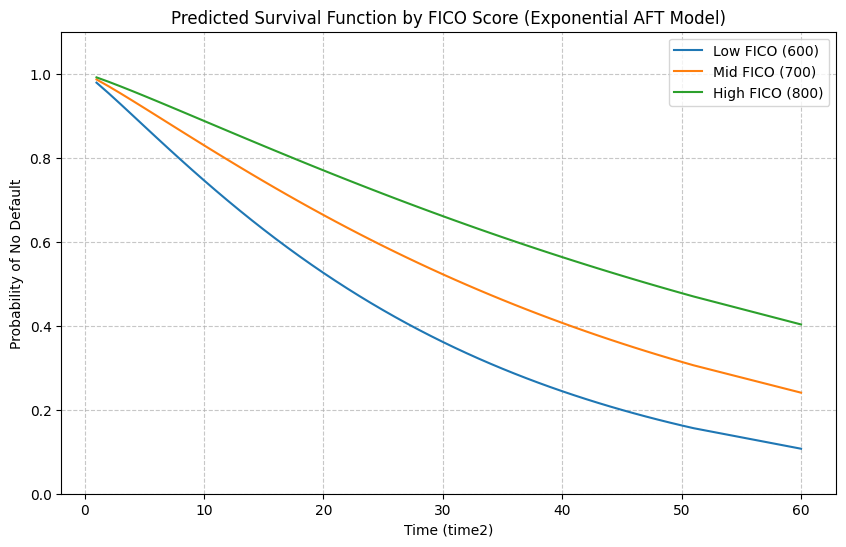

In [ ]:
mean_ltv = lifetest['LTV_orig_time'].mean()
scenarios = pd.DataFrame({
    'FICO_orig_time': [600, 700, 800],
    'LTV_orig_time': [mean_ltv, mean_ltv, mean_ltv]
}, index=['Low FICO (600)', 'Mid FICO (700)', 'High FICO (800)'])
survival_curves = aft.predict_survival_function(scenarios)
plt.figure(figsize=(10, 6))
plt.plot(survival_curves)
plt.title('Predicted Survival Function by FICO Score (Exponential AFT Model)')
plt.xlabel('Time (time2)')
plt.ylabel('Probability of No Default')
plt.legend(survival_curves.columns)
plt.grid(True, linestyle='--', alpha=0.7)
plt.ylim(0, 1.1) # Survival probability stays between 0 and 1

plt.show()

### Estimation of Default Probabilities

Estimation of default probabilities in Accelerated Failure Time (AFT) models is performed using survival probabilities. In an exponential model, the hazard rate ($\lambda_i$) is time-invariant, reflecting the memoryless property of the exponential distribution.

The default probability for a specific period is calculated as the first-order difference between the survival function at the beginning and the end of that period:

$$PD_{time} = \frac{S_i(t_1)-S_i(t_2)}{S_i(t_1)}$$

The survival probability is estimate using the following formula:

$$\hat{S}(t_i) = \exp(-\exp(-(\hat{\beta}_0 + \hat{\beta}_1 \times \text{FICO\_orig\_time} + \hat{\beta}_2 \times \text{LTV\_orig\_time}) \times t_i))$$

In [169]:
def calculate_pd(df, b0=2.0998, b1=0.0044, b2=-0.0159):
    """
    Replicates the SAS logic for lambda and PD_time calculation.
    """
    # xbeta = b0 + b1*FICO + b2*LTV
    df['xbeta'] = b0 + b1 * df['FICO_orig_time'] + b2 * df['LTV_orig_time']
    
    # lambda = EXP(-xbeta)
    df['lambda_val'] = np.exp(-df['xbeta'])
    
    # S1 = 1 - CDF('EXPONENTIAL', time1, 1/lambda)
    # S2 = 1 - CDF('EXPONENTIAL', time2, 1/lambda)
    df['S1'] = 1 - expon.cdf(df['time1'], scale=1/df['lambda_val'])
    df['S2'] = 1 - expon.cdf(df['time2'], scale=1/df['lambda_val'])
    
    # PD_time = (S1 - S2) / S1
    df['PD_time'] = (df['S1'] - df['S2']) / df['S1']
    return df

phreg_ = calculate_pd(mortgage_)
phreg_[['default_time', 'PD_time']].mean()


default_time    0.024351
PD_time         0.023513
dtype: float64

Let Y = 1 when an account is susceptible to default and Y=0 otherwise. Let x and z be costumer characteristics. You can think of characteristics such as age, income, marital status and so on. The mixture cure model then becomes:

$$S(t|x,z) = \pi(z)S(t|Y=1, x) + 1 - \pi(z)$$

Where

* **$\pi(z)$ (Incidence):** The probability of being susceptible to default ($Y=1$).
* **$S(t|Y=1, x)$ (Latency):** The survival probability for those who *are* susceptible.



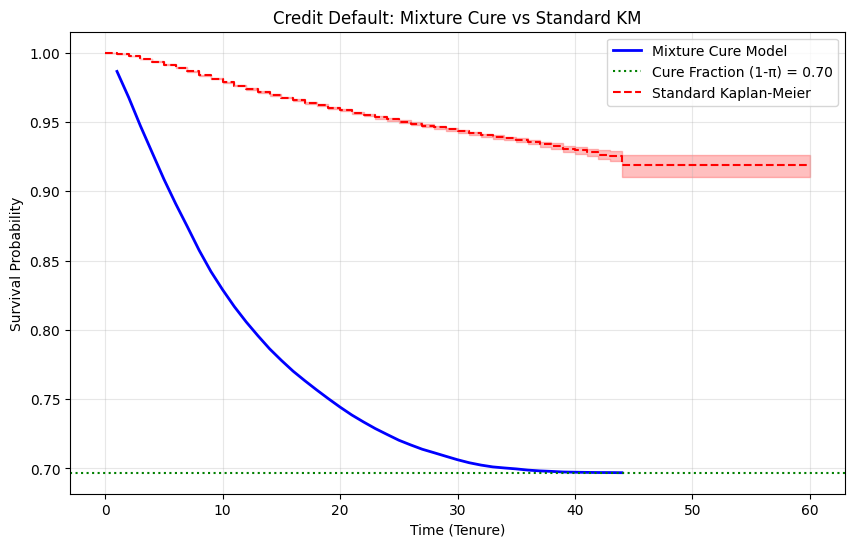

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxTimeVaryingFitter, KaplanMeierFitter
from sklearn.linear_model import LogisticRegression

# 1. Prepare Data
# Ensure we are working with clean rows for the features
phreg4 = mortgage_.dropna(subset=['time1', 'time2', 'FICO_orig_time', 'LTV_time']).copy()

# Since default_time is a flag (1 if default at time2, else 0)
# we find which IDs EVER defaulted to define the "Susceptible" population
ids_that_defaulted = phreg4.groupby('id')['default_time'].max()
phreg4['ever_defaulted'] = phreg4['id'].map(ids_that_defaulted).astype(int)

# 2. Incidence Model (The "If")
# We aggregate to one row per ID to see who is susceptible
incidence_df = phreg4.groupby('id').agg({
    'ever_defaulted': 'first', 
    'FICO_orig_time': 'first',
    'LTV_time': 'first'
}).reset_index()

X_inc = incidence_df[['FICO_orig_time', 'LTV_time']]
y_inc = incidence_df['ever_defaulted']

log_reg = LogisticRegression()
log_reg.fit(X_inc, y_inc)

# Probability of being susceptible (pi)
pi_z = log_reg.predict_proba(X_inc)[:, 1].mean()

# 3. Latency Model (The "When")
# Define the columns the Cox model actually needs to run
covariates = ['FICO_orig_time', 'LTV_time', 'gdp_time'] # Add any other features you use

# Select only the Susceptible population AND drop any row with ANY missing data
latency_data = phreg4[phreg4['ever_defaulted'] == 1].dropna(subset=covariates + ['time1', 'time2', 'default_time'])

if latency_data.empty:
    print("Error: No data left for Latency model after dropping NaNs. Check your features.")
else:
    ctv = CoxTimeVaryingFitter()
    # Note: We must specify the formula or the fitter will try to use 'id' or 'ever_defaulted' as features
    ctv.fit(latency_data, 
            id_col="id", 
            event_col="default_time", 
            start_col="time1", 
            stop_col="time2",
            formula=" + ".join(covariates)) # Forces model to only use specific features
    
# 4. Calculate Mixture Cure Survival
# S_mix(t) = pi * S_latency(t) + (1 - pi)
s_latent = ctv.baseline_survival_
mixture_survival = (pi_z * s_latent['baseline survival']) + (1 - pi_z)

# 5. Plotting

plt.figure(figsize=(10, 6))

# Mixture Cure Curve
plt.plot(s_latent.index, mixture_survival, label="Mixture Cure Model", color='blue', lw=2)
plt.axhline(1 - pi_z, color='green', linestyle=':', label=f'Cure Fraction (1-π) = {1-pi_z:.2f}')

# Reference Kaplan-Meier (Standard approach)
kmf = KaplanMeierFitter()
kmf.fit(phreg4['time2'], phreg4['default_time'], label="Standard Kaplan-Meier")
kmf.plot(ax=plt.gca(), color='red', linestyle='--')

plt.title("Credit Default: Mixture Cure vs Standard KM")
plt.ylabel("Survival Probability")
plt.xlabel("Time (Tenure)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()